# Load & Parse Data

In [5]:
import importlib
import utils.parse_data  

importlib.reload(utils.parse_data)

<module 'utils.parse_data' from 'C:\\Users\\bayer\\PycharmProjects\\fmri_connectivity\\forecasting\\utils\\parse_data.py'>

In [6]:
from utils.parse_data import parse_dataset

X_train, Y_train, X_test, Y_test, device = parse_dataset(M=50, H=3, normalize=True, stride=1, test_ratio=0.2,
                                                         test_subjects=None, random_state=42, verbose=True)

Using dataset path: data\train_pooled_stratified_share
Loading dataset with fixed schema settings...
Scanning and loading dataset (optimized fixed schema mode)...
Loaded: 2144 runs from 6 subjects
Subjects: ['subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Successfully loaded runs: 2144
Loading time: 1.84 seconds
Device: cuda
Normalizing dataset...
Building sliding windows...
Splitting by subject...
Train subjects: ['subjqFdsBbuiHF', 'subjoVC0sHUB_P', 'subjxpYwO4azeZ', 'subjtySNgRhV65']
Test subjects : ['subjQX6R7rImeb', 'subjOenz4SHyaO']
Train runs: 1440
Test runs : 704
Final shapes - Train: (250560, 50, 19), (250560, 3, 19) | Test: (122496, 50, 19), (122496, 3, 19)


In [16]:
from models.transformer.transformer_api_library import transformer_model_generator, TransformerPredictorAPI

# Build transformer

model = transformer_model_generator(
    n_roi=19,
    M=50,
    H=3,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.1,
)

model = model.to(device)

In [21]:
from utils.training import train_forecasting_model

# Train Model
model = train_forecasting_model(
    model,
    X_train,
    Y_train,
    X_val=X_test,
    Y_val=Y_test,
    batch_size=512,
    num_epochs=1,
    device=device,
)

Epoch 1/1:   0%|          | 0/490 [00:00<?, ?it/s]

  Epoch  1 | train: 0.281184 | val: 0.262793
  Best val loss: 0.262793 | weights restored


In [37]:
from utils.measures import fit_histogram_proba_adapter

# Wrap with API
config = {
    "window_size": 50,
    "predict_step": 3,
    "output_horizon": 3,
    "input_dim": 19,
    "d_model": 64,
    "nhead": 4,
    "num_layers": 2,
    "dropout": 0.1,
}

api_model = TransformerPredictorAPI(
    model=model,
    config=config,
    stats={},
    device=device,
)

# Build histogram likelihood adapter
hist_model = fit_histogram_proba_adapter(
    base_model=api_model,
    X_calib=X_test,
    Y_calib=Y_test,
    n_bins=50,
    flatten_input=False,
)

In [38]:
import importlib
import utils.measures  

importlib.reload(utils.measures)

<module 'utils.measures' from 'C:\\Users\\bayer\\PycharmProjects\\fmri_connectivity\\forecasting\\utils\\measures.py'>

In [39]:
from utils.measures import compute_di_from_log_prob_api

DI_flow = compute_di_from_log_prob_api(
    model=hist_model,
    X=X_test,
    Y=Y_test,
    horizon_idx=0,
    reduction_mode="zero",
)

Computing DI:   0%|          | 0/361 [00:00<?, ?it/s]

In [40]:
DI_flow.shape

#DI_flow


(19, 19)

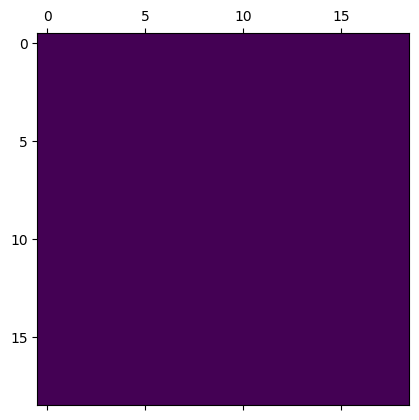

In [41]:
import matplotlib.pyplot as plt

plt.matshow(DI_flow)